# Glastonbury Ticket Syndicate

## Setup
- Can buy batches of 6 tickets at a time
- So make a big spreadsheet of groups of 6
- If you get through you buy for yourself first and if your group already has a ticket for another group in the spreadsheet

## Maths

Let 
- $N$ be the total number of active applicants trying for tickets.
- $T$ be the total number of tickets available.
- $n$ be the number of people in a single group.
- $m$ be the total number of groups in the syndicate.
- $c$ be the average number of tickets purchased per transaction across all applicants

Each individual transaction allows the purchase of up to $n$ tickets. Therefore, the total number of successful transactions the system will allow is $T/c$

Each individual has an independent probability $q$ of securing one of those transactions:

$$q = \frac{T/c}{N}$$

If an individual successfully gets through the queue, they secure exactly one group's worth of tickets (funding exactly 1 of the $m$ groups).

The total number of successes $S$ generated by the syndicate follows a Binomial distribution: $S \sim \text{Binomial}(mn, q)$.

The probability of any individual group getting a ticket is exactly equal to the expected proportion of the syndicate that gets funded:


$$P(\text{Group Ticket}) = \frac{E[\min(S, m)]}{m}$$

### Theoretical Maximum ($m \to \infty$)
The number of funded groups cannot exceed the total successes: $\min(S, m) \le S$.

Taking expectations:
$$E[\min(S, m)] \le E[S]$$
Since $S \sim \text{Binomial}(mn, q)$, the expected number of syndicate successes is $E[S] = mnq$:
$$E[\min(S, m)] \le mnq$$
Dividing by the number of groups $m$:
$$P(\text{Group Ticket}) = \frac{E[\min(S, m)]}{m} \le nq$$
As the syndicate grows ($m \to \infty$), the chance of wasting duplicate wins drops to zero, and the probability approaches this theoretical limit $nq$.


### Modelling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom

### Variables

Change based on optimism

In [2]:
N = 2_500_000 * 0.8  # Total active applicants trying on the day (2.5M is total registered)
c = 4         # Average number of tickets bought per group 
T = 135_000     # Total general admission tickets available
n = 6           # Number of people per group
max_m = 10      # Maximum number of groups in the syndicate to model

In [3]:
# Calculate the independent probability of one person getting through (q)
q = (T / c) / N 

print(f"Individual probability of getting through (q): {q:.4f} ({q*100:.2f}%)")

Individual probability of getting through (q): 0.0169 (1.69%)


In [4]:
results = []
m_values = list(range(1, max_m + 1))

for m in m_values:
    total_people = m * n
    
    # Array representing every possible number of successes (0 to total_people)
    k = np.arange(total_people + 1)
    
    # Calculate the binomial probability for exactly 'k' successes
    # Technically this is with replacement but there's lots of tickets
    # So a fair approx
    # P(S = k)
    probabilities = binom.pmf(k, total_people, q)
    
    # Calculate how many groups get tickets for each 'k'
    # Cap the funded groups at 'm' (since you only need m successes to fund everyone)
    funded_groups = np.minimum(k, m)
    
    # The Expected Value (E) is the sum of (outcome * probability of outcome)
    expected_funded = np.sum(funded_groups * probabilities)
    
    # The probability for an individual group is Expected Funded / Total Groups
    group_ticket_prob = expected_funded / m
    
    results.append({
        "Syndicate Groups (m)": m,
        "Total People Trying": total_people,
        "Individual Group Win Probability": group_ticket_prob,
        "Any Group Win Probability": (1 - (1 - q) ** total_people)
    })

In [5]:
df = pd.DataFrame(results)

# Format the probability as a percentage for the table
df_display = df.copy()
df_display['Individual Group Win Probability'] = (df_display['Individual Group Win Probability'] * 100).round(2).astype(str) + '%'
df_display['Any Group Win Probability'] = (df_display['Any Group Win Probability'] * 100).round(2).astype(str) + '%'

df_display

,Syndicate Groups (m),Total People Trying,Individual Group Win Probability,Any Group Win Probability
0,1,6,9.71%,9.71%
1,2,12,10.08%,18.47%
2,3,18,10.12%,26.39%
3,4,24,10.12%,33.53%
4,5,30,10.12%,39.98%
5,6,36,10.12%,45.81%
6,7,42,10.12%,51.07%
7,8,48,10.12%,55.82%
8,9,54,10.12%,60.11%
9,10,60,10.12%,63.98%


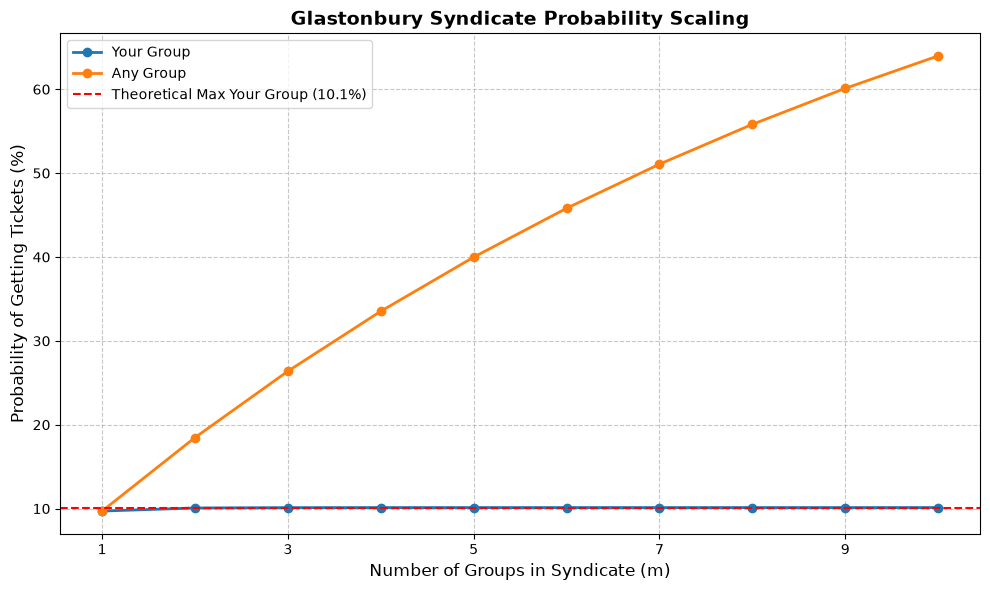

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(
    df["Syndicate Groups (m)"], 
    df["Individual Group Win Probability"] * 100, 
    marker='o', 
    linestyle='-', 
    # color='#1db954', # Glastonbury-ish green
    linewidth=2,
    label="Your Group"
)

plt.plot(
    df["Syndicate Groups (m)"], 
    df["Any Group Win Probability"] * 100, 
    marker='o', 
    linestyle='-', 
    # color='#1db954', # Glastonbury-ish green
    linewidth=2,
    label="Any Group"
)

# Plot the theoretical absolute limit (6 * q)
max_prob = min((n * q) * 100, 100)
plt.axhline(y=max_prob, color='red', linestyle='--', label=f'Theoretical Max Your Group ({max_prob:.1f}%)')

# Formatting the graph
plt.title('Glastonbury Syndicate Probability Scaling', fontsize=14, fontweight='bold')
plt.xlabel('Number of Groups in Syndicate (m)', fontsize=12)
plt.ylabel("Probability of Getting Tickets (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(np.arange(1, max_m + 1, step=2))

# Display the plot
plt.tight_layout()
plt.savefig("figures/plot.png")
plt.show()

## Takeaways

- Being in a group of 6 makes a huge difference over trying to get a ticket by yourself
- Being in a syndicate makes ~negligible difference and none after 3 groups!!
    - The only mathematical advantage of a syndicate is capturing "duplicate wins" (when $\ge 2$ people in the same group of 6 succeed at the same time).
    - Because $q$ is small ($1.69\%$), the probability of two or more successes within any single 6-person group is tiny: $$P(S \ge 2) = 1 - (1-q)^6 - 6q(1-q)^5 \approx 0.41\%$$